In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Load the data
sinogram = np.load('/Users/g.j.kim/Downloads/sinogram.npy')
sinogram.shape

(512, 180)

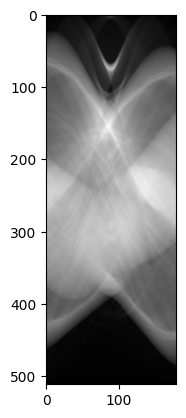

In [4]:
plt.imshow(sinogram, cmap='gray') # 해당조직의 그림자. 조직의 두께에 따라 달라짐

In [5]:
sinogram = sinogram.T
sinogram.shape

(180, 512)

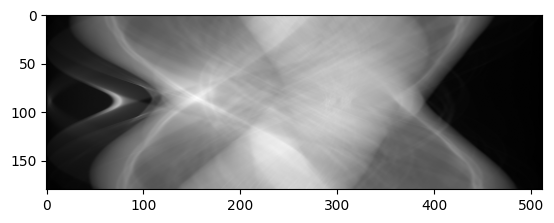

In [6]:
plt.imshow(sinogram, cmap='gray')

In [7]:
sinogram[0] # theta 0에 해당하는 sinogram값

array([  1337.3376203 ,   2999.80624961,   3894.02907581,   4277.60908898,
         4661.74547128,   5059.57299741,   6522.15961319,   7036.287748  ,
         7642.65604184,   8240.0674216 ,   8185.020721  ,   7384.59797799,
         6491.20845066,   6099.63676693,   6370.18950283,   7160.54672272,
         8042.14611636,   9665.93185306,  10669.0697602 ,  10968.66644344,
        11240.32575277,  11814.23900682,  12535.34445016,  14301.98439704,
        19319.0555028 ,  28723.98705598,  40916.10929886,  51840.96670886,
        59779.3886844 ,  66234.00682084,  72355.97749964,  78365.09575346,
        84406.68640842,  90060.04135629,  94890.64254756,  98932.36494792,
       102548.27944785, 106129.22507626, 110180.29905052, 113830.9907294 ,
       117230.33777137, 120965.85043894, 124372.2710827 , 127483.39975542,
       130205.40023688, 132831.96100404, 135473.06999912, 137810.72232539,
       140678.15124782, 144065.92531781, 147396.69871948, 151430.00533602,
       155413.40090947, 1

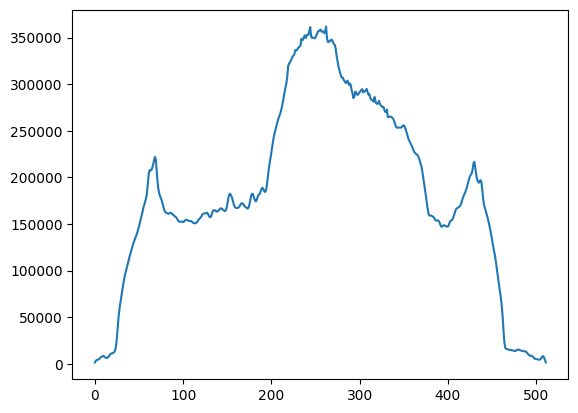

In [8]:
theta = 0
plt.plot(sinogram[theta]) # 1d sinogram

# Back Projection 

In [9]:
from scipy.ndimage import rotate
images = []
for i in range(sinogram.shape[0]):
    image = []
    for j in range(sinogram.shape[1]):
        image.append(sinogram[i])
    image = rotate(image, i+1, reshape=False)
    images.append(np.array(image))
images = np.array(images)
images.shape

(180, 512, 512)

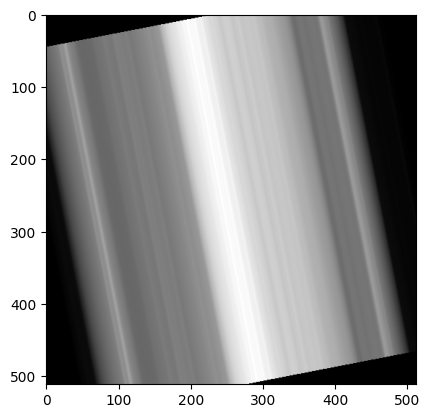

In [10]:
plt.imshow(images[10], cmap='gray')

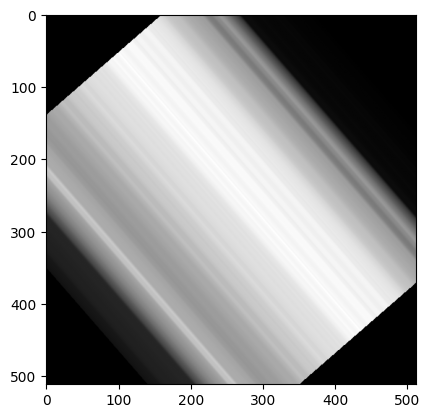

In [11]:
plt.imshow(images[40], cmap='gray')

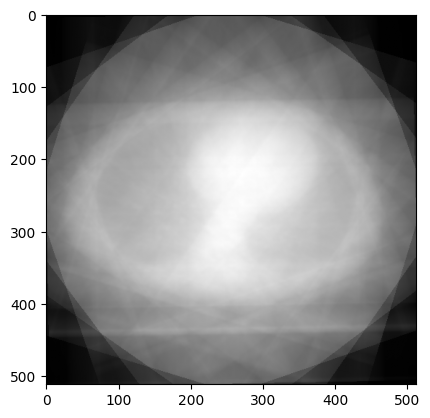

In [12]:
# 10 imgs sum
sum_10 = images[::18].sum(axis=0)
plt.imshow(sum_10, cmap='gray')

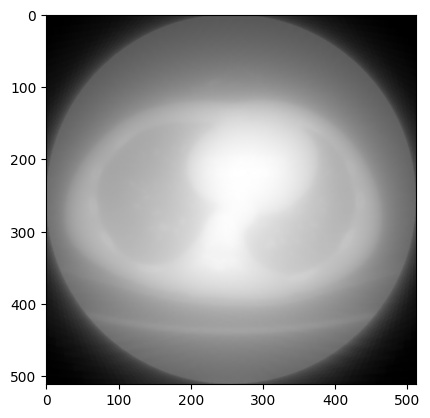

In [13]:
# 60 imgs sum
sum_60 = images[::3].sum(axis=0)
plt.imshow(sum_60, cmap='gray')   

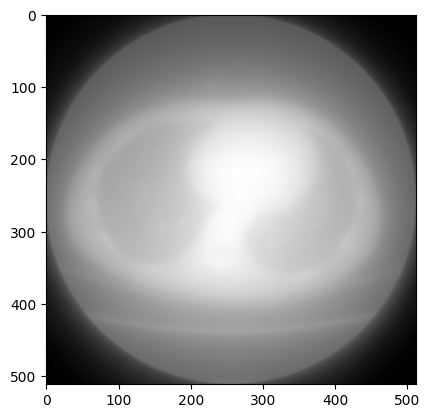

In [14]:
# 180 imgs sum
sum_all = images.sum(axis=0)
sum_all.shape
plt.imshow(sum_all, cmap='gray')

/var/folders/wy/8fvw_q1955v9yxg3h73mwc1c0000gn/T/ipykernel_44753/504193746.py:4: RuntimeWarning: divide by zero encountered in log10
  sum_all_db = 20 * np.log10(sum_all_db)


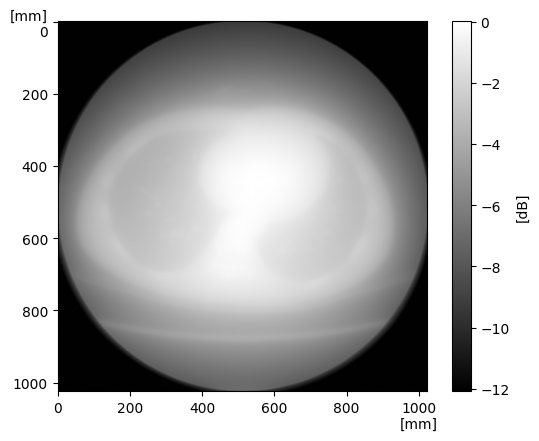

In [15]:
import scipy

sum_all_db = sum_all - sum_all.min()
sum_all_db = 20 * np.log10(sum_all_db)
sum_all_db = sum_all_db - np.max(sum_all_db)
sum_all_db = np.maximum(sum_all_db, -12)

conversion_image = scipy.ndimage.zoom(sum_all_db, (2, 2))
plt.imshow(conversion_image, cmap='gray')
plt.xticks(np.arange(0, 1025, 200), labels=['0', '200', '400', '600', '800', '1000\n[mm]'])
plt.yticks(np.arange(0, 1025, 200), labels=['[mm]\n0', '200', '400', '600', '800', '1000'])
plt.colorbar(label='[dB]')

# FBP 

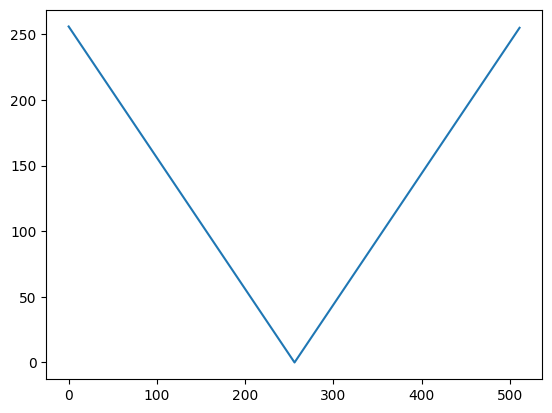

In [16]:
abs_ramp = []
for i in range(-256, 256):
    abs_ramp.append(np.abs(i))
abs_ramp = np.array(abs_ramp)

plt.plot(abs_ramp)

In [17]:
from scipy.fft import fft ,fftshift, ifft

sino_fft = fft(sinogram, axis=1)
sino_fftshift = fftshift(sino_fft, axes=(1,))
sino_fftshift.shape

(180, 512)

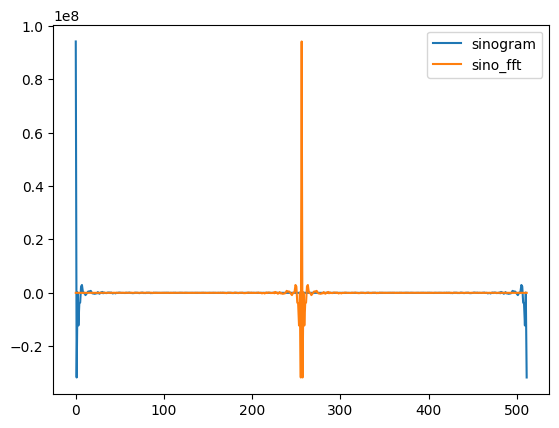

In [20]:
plt.plot(sino_fft[0])
plt.plot(sino_fftshift[0])
plt.legend(['sinogram', 'sino_fft'])
plt.show()

In [21]:
abs_ramp_fftsinogram = []
for th in range(sino_fftshift.shape[0]):
    abs_ramp_fftsinogram.append(sino_fftshift[th]*abs_ramp)
abs_ramp_fftsinogram = np.array(abs_ramp_fftsinogram)
abs_ramp_fftsinogram.shape

(180, 512)

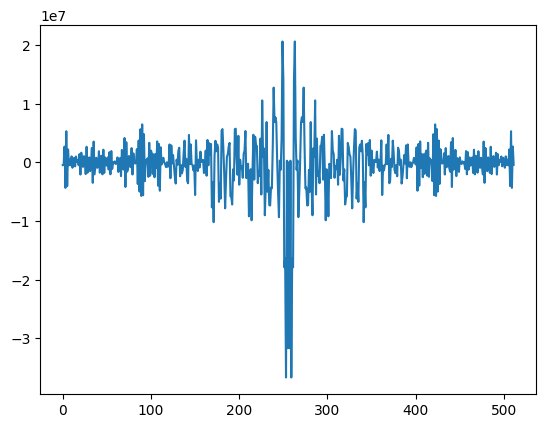

In [22]:
plt.plot(abs_ramp_fftsinogram[0])

In [23]:
abs_ramp_ifftsinogram = ifft(abs_ramp_fftsinogram, axis=1)

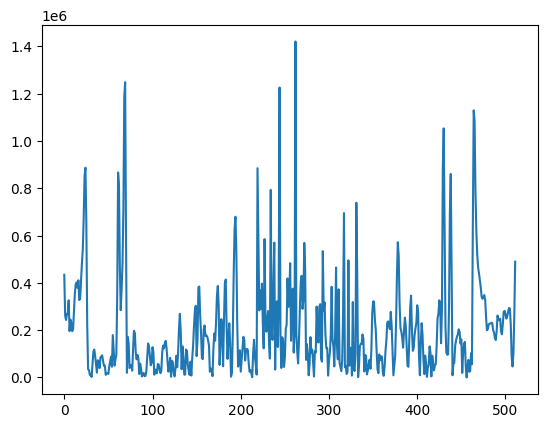

In [24]:
plt.plot(np.abs(abs_ramp_ifftsinogram[0]))

In [25]:
conversion_images = []
for i in range(abs_ramp_ifftsinogram.shape[0]):
    img = []
    for j in range(abs_ramp_ifftsinogram.shape[1]):
        img.append(np.abs(abs_ramp_ifftsinogram[i]))
    img = rotate(img, i+1, reshape=False)
    conversion_images.append(np.array(img))
conversion_images = np.array(conversion_images)
conversion_images.shape

(180, 512, 512)

In [26]:
conversion_images -= conversion_images.min()

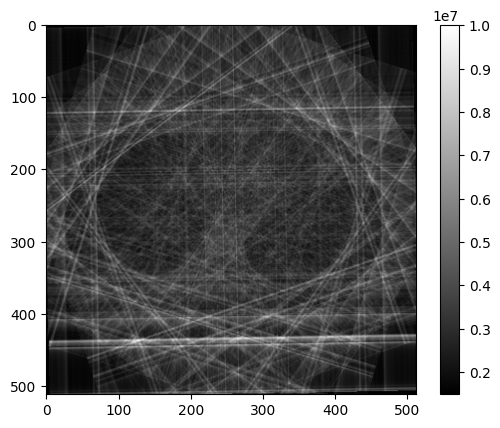

In [27]:
# 10 imgs sum
conversion_images_sum_10 = conversion_images[::18].sum(axis=0)
plt.imshow(conversion_images_sum_10, cmap='gray')
plt.colorbar()

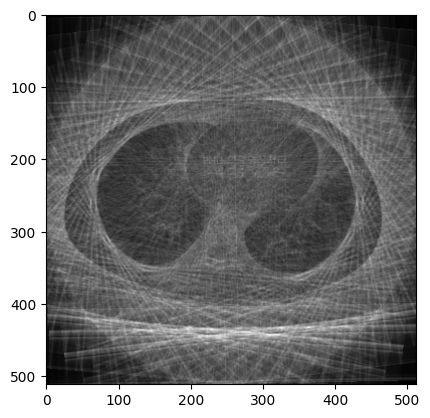

In [28]:
# 30 imgs sum
conversion_images_sum_30 = conversion_images[::6].sum(axis=0) / 30
plt.imshow(conversion_images_sum_30, cmap='gray')

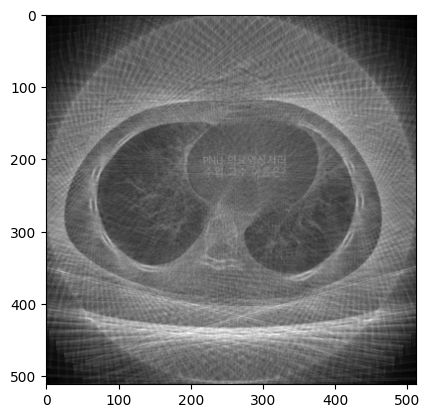

In [29]:
# 60 imgs sum
conversion_images_sum_60 = conversion_images[::3].sum(axis=0) / 60
plt.imshow(conversion_images_sum_60, cmap='gray')


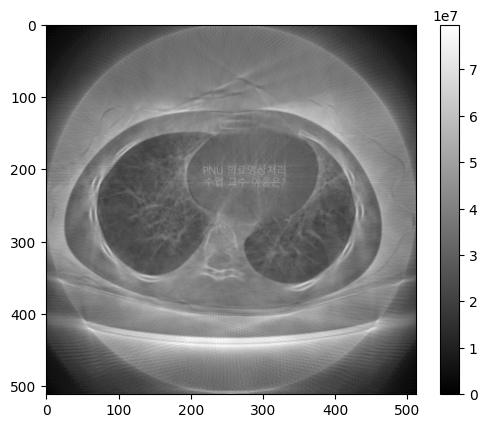

In [30]:
# 180 imgs sum
conversion_images_sum = conversion_images.sum(axis=0)
conversion_images_sum -= np.min(conversion_images_sum)
plt.imshow(conversion_images_sum, cmap='gray')
plt.colorbar()

In [31]:
dynamic_db = 12
conv_imgs_sum_db = 20*np.log10(conversion_images_sum)
conv_imgs_sum_db = conv_imgs_sum_db - np.max(conv_imgs_sum_db)
conv_imgs_sum_db = np.maximum(conv_imgs_sum_db, -dynamic_db)

/var/folders/wy/8fvw_q1955v9yxg3h73mwc1c0000gn/T/ipykernel_44753/4143566776.py:2: RuntimeWarning: divide by zero encountered in log10
  conv_imgs_sum_db = 20*np.log10(conversion_images_sum)


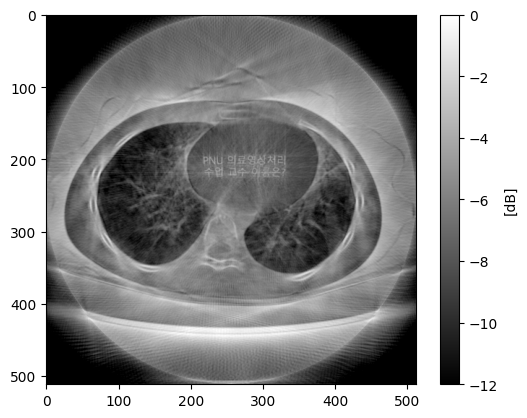

In [32]:
plt.imshow(conv_imgs_sum_db, cmap='gray')
plt.colorbar(label='[dB]')

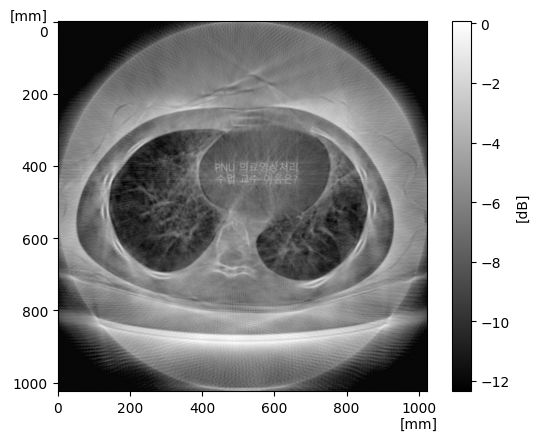

In [33]:
import scipy

scanned_conversion_img = scipy.ndimage.zoom(conv_imgs_sum_db, (2, 2))
plt.imshow(scanned_conversion_img, cmap='gray')
plt.xticks(np.arange(0, 1025, 200), labels=['0', '200', '400', '600', '800', '1000\n[mm]'])
plt.yticks(np.arange(0, 1025, 200), labels=['[mm]\n0', '200', '400', '600', '800', '1000'])
plt.colorbar(label='[dB]')